# cad dataset baseline


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['figure.dpi'] = 300

from ts_toolkit.io import clean_timeseries
from ts_toolkit.calendar import add_hour_sin_cos
from ts_toolkit.viz import plot_history_forecast
from ts_toolkit.split import three_way_split
from ts_toolkit.metrics import daily_mae
from ts_toolkit.metrics import global_metrics

In [ ]:
from src.data_loader import fetch_frame
# df = fetch_frame()
df = fetch_frame(
    start_date="2024-11-25 18:00:00",
    end_date  ="2024-12-11 10:50:00",
    use_cache=True,             # всегда тянуть свежие данные
    cache_filename="common_cad_20241125_20241211.parquet",
    # verbose=True                 # чтобы видеть прогресс
)
df.rename(columns={'common_cad_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'common_cad'}, inplace=True)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())


In [3]:
df = clean_timeseries(df, 'common_cad')

In [4]:
df_train, df_val, df_hold = three_way_split(df, train_ratio=0.8, val_ratio=0.19)

In [ ]:
# last element of df_train
df_val['common_cad'].tail(1)

In [6]:
# i want to make list of last element of df_val by len of df_hold

# last element of df_val
last_element_df_val = df_val['common_cad'].tail(1)

# len of df_hold
len_df_hold = len(df_hold)

# make list of last element of df_val by len of df_hold
list_of_last_elements = [float(last_element_df_val.iloc[0])] * len_df_hold

# print list_of_last_elements
# list_of_last_elements

In [7]:
# i want to make list of avg elemet by 15 minutes of concat df_train and df_val

# concat df_train and df_val
df_train_val = pd.concat([df_train, df_val])

# make list of avg elemet of df_train_val
list_of_avg_elements = [float(df_train_val['common_cad'].mean())] * len(df_hold)

# print list_of_avg_elements
# list_of_avg_elements

In [8]:
# i want to make list of avg elements by last 15 minutes of concat df_train and df_val by len of df_hold

# Concatenate df_train and df_val
combined_df = pd.concat([df_train, df_val])

# Get the timestamp for 15 minutes before the last entry in combined_df
last_timestamp = combined_df.index[-1]
time_window_start = last_timestamp - pd.Timedelta(minutes=15)

# Filter data for the last 15 minutes and calculate the average
last_15_min_data = combined_df.loc[time_window_start:last_timestamp, 'common_cad']
avg_last_15_minutes = last_15_min_data.mean()

# Create a list of this average, repeated len_df_hold times
list_of_avg_last_15_minutes_elements = [float(avg_last_15_minutes)] * len(df_hold)

# print list_of_avg_last_15_minutes_elements
# list_of_avg_last_15_minutes_elements



In [10]:
y_true = df_hold['common_cad']
pred_idx = df_hold.index

In [ ]:
# y_true и y_pred уже созданы в предыдущей ячейке

metrics = global_metrics(y_true, list_of_last_elements)
print(f"Blind 24-h test • MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
      f"on {len(y_true)} valid points")

# ── график: история 3 сут + прогноз vs факт ──
# hist_start = pred_idx[0] - pd.Timedelta(hours=1)
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], 'common_cad'],
    forecast = pd.Series(list_of_last_elements, index=pred_idx),
    actual   = y_true,
    title    = 'Blind forecast vs actual — hold-out 24 h'
)

In [ ]:
# y_true и y_pred уже созданы в предыдущей ячейке

metrics = global_metrics(y_true, list_of_avg_elements)
print(f"Blind 24-h test • MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
      f"on {len(y_true)} valid points")

# ── график: история 3 сут + прогноз vs факт ──
# hist_start = pred_idx[0] - pd.Timedelta(hours=1)
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], 'common_cad'],
    forecast = pd.Series(list_of_avg_elements, index=pred_idx),
    actual   = y_true,
    title    = 'Blind forecast vs actual — hold-out 24 h'
)

In [ ]:
# y_true и y_pred уже созданы в предыдущей ячейке

metrics = global_metrics(y_true, list_of_avg_last_15_minutes_elements)
print(f"Blind 24-h test • MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f}  MAPE={metrics['MAPE']:.2f}%  "
      f"on {len(y_true)} valid points")

# ── график: история 3 сут + прогноз vs факт ──
# hist_start = pred_idx[0] - pd.Timedelta(hours=1)
hist_start = pred_idx[0] - pd.Timedelta(minutes=30)
plot_history_forecast(
    history  = df.loc[hist_start:pred_idx[0], 'common_cad'],
    forecast = pd.Series(list_of_avg_last_15_minutes_elements, index=pred_idx),
    actual   = y_true,
    title    = 'Blind forecast vs actual — hold-out 24 h'
)

## TimeSeriesSplit валидация

Анализ на разных временных участках с test_size=900


In [24]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Подготавливаем данные для TimeSeriesSplit
data = df['common_cad'].values
test_size = 900

# Создаем TimeSeriesSplit с 5 фолдами
tscv = TimeSeriesSplit(n_splits=5, test_size=test_size)

# Результаты для каждого фолда
fold_results = []

print(f"Анализируем {len(data)} точек с test_size={test_size}")
print("-" * 60)

for fold, (train_idx, test_idx) in enumerate(tscv.split(data)):
    print(f"Fold {fold + 1}: train={len(train_idx)}, test={len(test_idx)}")
    
    # Данные для текущего фолда
    train_data = data[train_idx]
    test_data = data[test_idx]
    
    # Временные индексы
    train_time_idx = df.index[train_idx]
    test_time_idx = df.index[test_idx]
    
    # Простые baseline предсказания для теста
    
    # 1. Последнее значение из train
    last_train_value = train_data[-1]
    pred_last = np.full(len(test_data), last_train_value)
    
    # 2. Среднее по всему train
    train_mean = np.mean(train_data)
    pred_mean = np.full(len(test_data), train_mean)
    
    # 3. Среднее по последним 15 минутам train (60 точек при 15сек интервале)
    last_60_points = min(60, len(train_data))
    train_last_mean = np.mean(train_data[-last_60_points:])
    pred_last_mean = np.full(len(test_data), train_last_mean)
    
    # Вычисляем метрики для каждой стратегии
    metrics_last = global_metrics(test_data, pred_last)
    metrics_mean = global_metrics(test_data, pred_mean)
    metrics_last_mean = global_metrics(test_data, pred_last_mean)
    
    # Сохраняем результаты
    fold_results.append({
        'fold': fold + 1,
        'train_start': train_time_idx[0],
        'train_end': train_time_idx[-1],
        'test_start': test_time_idx[0], 
        'test_end': test_time_idx[-1],
        'mae_last': metrics_last['MAE'],
        'mae_mean': metrics_mean['MAE'],
        'mae_last_mean': metrics_last_mean['MAE'],
        'rmse_last': metrics_last['RMSE'],
        'rmse_mean': metrics_mean['RMSE'],
        'rmse_last_mean': metrics_last_mean['RMSE'],
        'mape_last': metrics_last['MAPE'],
        'mape_mean': metrics_mean['MAPE'],
        'mape_last_mean': metrics_last_mean['MAPE'],
        'test_mean': np.mean(test_data),
        'test_std': np.std(test_data)
    })
    print(f"  Train period: {train_time_idx[0]} - {train_time_idx[-1]}")
    print(f"  Test period: {test_time_idx[0]} - {test_time_idx[-1]}")
    print(f"  MAE: last={metrics_last['MAE']:.1f}, mean={metrics_mean['MAE']:.1f}, last_15min={metrics_last_mean['MAE']:.1f}")
    print(f"  RMSE: last={metrics_last['RMSE']:.1f}, mean={metrics_mean['RMSE']:.1f}, last_15min={metrics_last_mean['RMSE']:.1f}")
    print(f"  MAPE: last={metrics_last['MAPE']:.1f}, mean={metrics_mean['MAPE']:.1f}, last_15min={metrics_last_mean['MAPE']:.1f}")
    print()

# Создаем DataFrame с результатами
results_df = pd.DataFrame(fold_results)
print("Сводка по всем фолдам:")
print(results_df[['fold', 'mae_last', 'mae_mean', 'mae_last_mean', 'rmse_last', 'rmse_mean', 'rmse_last_mean', 'mape_last', 'mape_mean', 'mape_last_mean']].round(1))


Анализируем 90437 точек с test_size=900
------------------------------------------------------------
Fold 1: train=85937, test=900
  Train period: 2024-11-25 18:01:00 - 2024-12-10 16:05:00
  Test period: 2024-12-10 16:05:15 - 2024-12-10 19:50:00
  MAE: last=84.4, mean=69.2, last_15min=77.0
  RMSE: last=106.1, mean=85.8, last_15min=98.0
  MAPE: last=23.5, mean=17.4, last_15min=21.3

Fold 2: train=86837, test=900
  Train period: 2024-11-25 18:01:00 - 2024-12-10 19:50:00
  Test period: 2024-12-10 19:50:15 - 2024-12-10 23:35:00
  MAE: last=112.7, mean=84.1, last_15min=83.3
  RMSE: last=141.5, mean=109.0, last_15min=110.3
  MAPE: last=34.1, mean=23.1, last_15min=23.7

Fold 3: train=87737, test=900
  Train period: 2024-11-25 18:01:00 - 2024-12-10 23:35:00
  Test period: 2024-12-10 23:35:15 - 2024-12-11 03:20:00
  MAE: last=140.5, mean=52.0, last_15min=66.4
  RMSE: last=155.0, mean=66.5, last_15min=81.7
  MAPE: last=37.5, mean=13.6, last_15min=18.2

Fold 4: train=88637, test=900
  Train perio

In [27]:
# Средние метрики по всем фолдам
print("\nСредние метрики по всем фолдам:")
mean_metrics = results_df[['mae_last', 'mae_mean', 'mae_last_mean', 'rmse_last', 'rmse_mean', 'rmse_last_mean', 'mape_last', 'mape_mean', 'mape_last_mean']].mean()
print(mean_metrics.round(1))

print("\nСтандартные отклонения метрик:")
std_metrics = results_df[['mae_last', 'mae_mean', 'mae_last_mean', 'rmse_last', 'rmse_mean', 'rmse_last_mean', 'mape_last', 'mape_mean', 'mape_last_mean']].std()
print(std_metrics.round(1))

# Лучшая стратегия по среднему MAE
best_strategy_mae = mean_metrics[['mae_last', 'mae_mean', 'mae_last_mean', 'mape_last', 'mape_mean', 'mape_last_mean']].idxmin()
print(f"\nЛучшая стратегия по MAE: {best_strategy_mae} = {mean_metrics[best_strategy_mae]:.1f}")

best_strategy_rmse = mean_metrics[['rmse_last', 'rmse_mean', 'rmse_last_mean', 'mape_last', 'mape_mean', 'mape_last_mean']].idxmin()
print(f"Лучшая стратегия по RMSE: {best_strategy_rmse} = {mean_metrics[best_strategy_rmse]:.1f}")



Средние метрики по всем фолдам:
mae_last          113.9
mae_mean           77.8
mae_last_mean      81.0
rmse_last         137.7
rmse_mean          99.8
rmse_last_mean    105.3
mape_last          32.4
mape_mean          20.5
mape_last_mean     21.7
dtype: float64

Стандартные отклонения метрик:
mae_last          20.9
mae_mean          17.2
mae_last_mean      9.8
rmse_last         20.9
rmse_mean         23.6
rmse_last_mean    16.6
mape_last          5.6
mape_mean          4.8
mape_last_mean     2.1
dtype: float64

Лучшая стратегия по MAE: mape_mean = 20.5
Лучшая стратегия по RMSE: mape_mean = 20.5


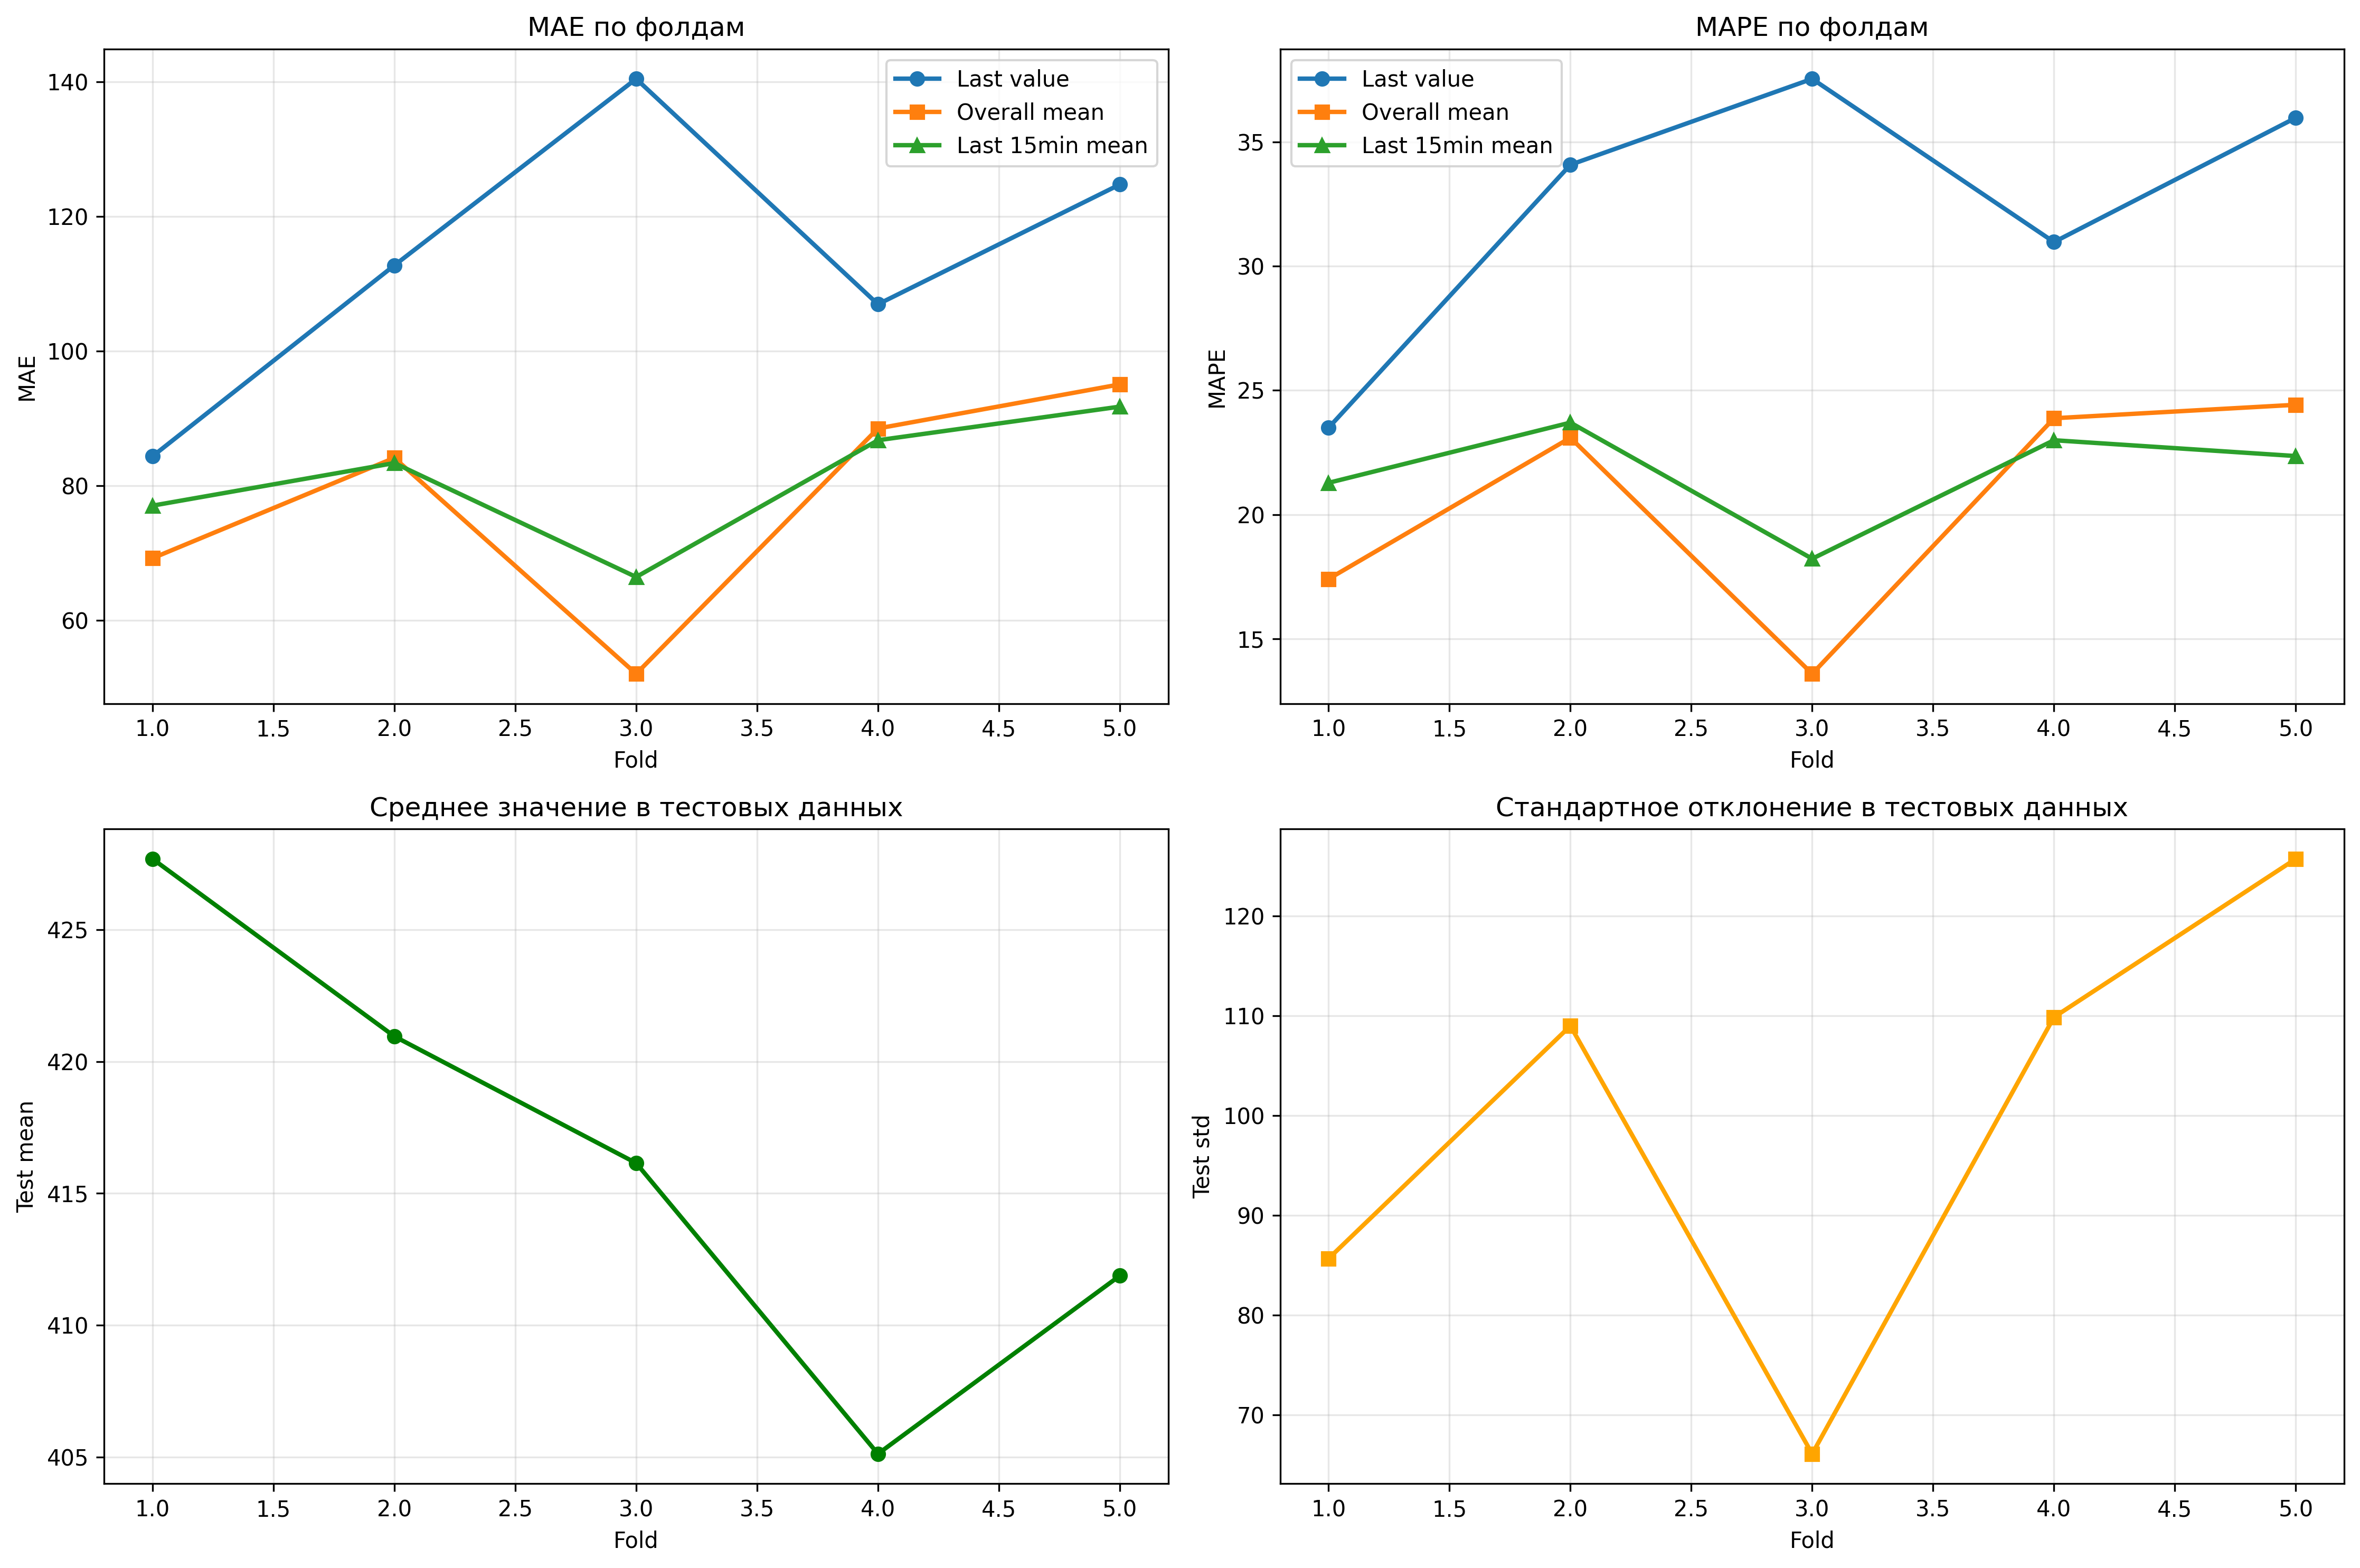

In [29]:
# Визуализация результатов TimeSeriesSplit
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Метрики по фолдам
axes[0,0].plot(results_df['fold'], results_df['mae_last'], 'o-', label='Last value', linewidth=2)
axes[0,0].plot(results_df['fold'], results_df['mae_mean'], 's-', label='Overall mean', linewidth=2)
axes[0,0].plot(results_df['fold'], results_df['mae_last_mean'], '^-', label='Last 15min mean', linewidth=2)
axes[0,0].set_title('MAE по фолдам')
axes[0,0].set_xlabel('Fold')
axes[0,0].set_ylabel('MAE')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(results_df['fold'], results_df['mape_last'], 'o-', label='Last value', linewidth=2)
axes[0,1].plot(results_df['fold'], results_df['mape_mean'], 's-', label='Overall mean', linewidth=2)
axes[0,1].plot(results_df['fold'], results_df['mape_last_mean'], '^-', label='Last 15min mean', linewidth=2)
axes[0,1].set_title('MAPE по фолдам')
axes[0,1].set_xlabel('Fold')
axes[0,1].set_ylabel('MAPE')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Статистики тестовых данных
axes[1,0].plot(results_df['fold'], results_df['test_mean'], 'o-', color='green', linewidth=2)
axes[1,0].set_title('Среднее значение в тестовых данных')
axes[1,0].set_xlabel('Fold')
axes[1,0].set_ylabel('Test mean')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(results_df['fold'], results_df['test_std'], 's-', color='orange', linewidth=2)
axes[1,1].set_title('Стандартное отклонение в тестовых данных')
axes[1,1].set_xlabel('Fold')
axes[1,1].set_ylabel('Test std')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


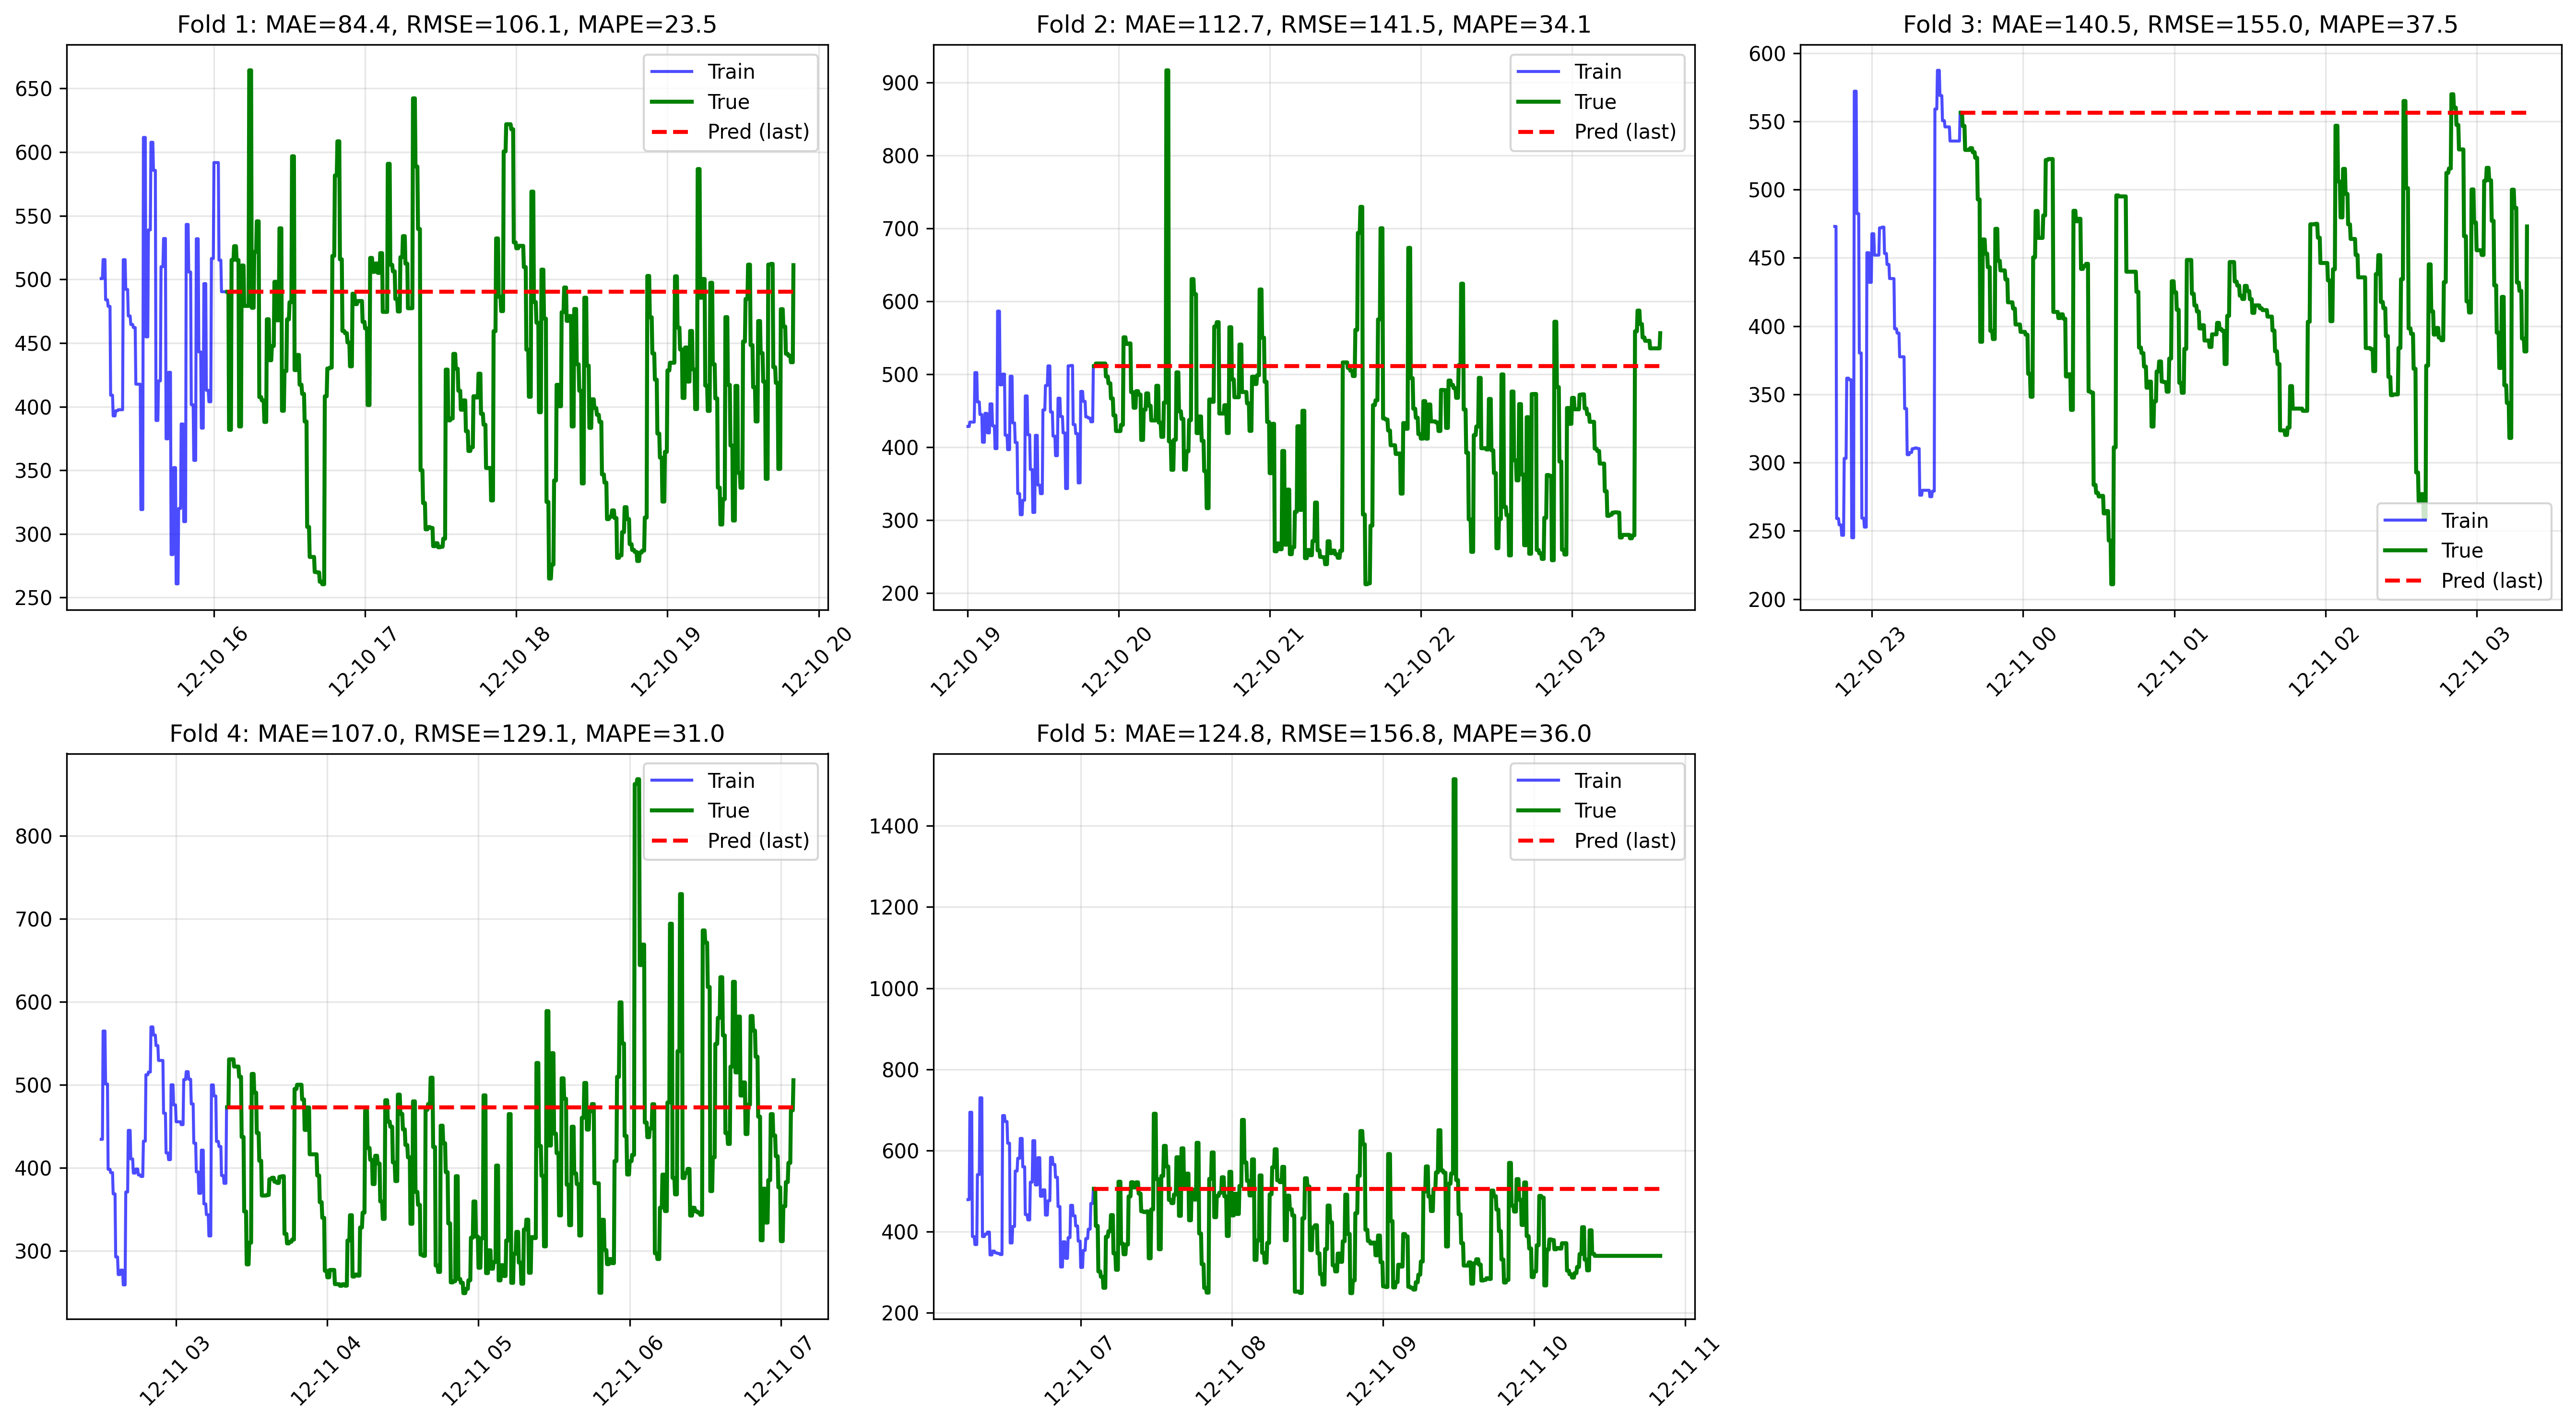

In [23]:
# Детальный анализ каждого фолда - примеры прогнозов
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, fold_idx in enumerate([0, 1, 2, 3, 4]):  # Показываем все 5 фолдов
    if i >= len(axes):
        break
        
    # Получаем индексы для текущего фолда
    train_idx, test_idx = list(tscv.split(data))[fold_idx]
    
    # Данные
    train_data = data[train_idx]
    test_data = data[test_idx]
    train_time = df.index[train_idx]
    test_time = df.index[test_idx]
    
    # Прогнозы
    last_train_value = train_data[-1]
    pred_last = np.full(len(test_data), last_train_value)
    
    # Показываем последние 200 точек train + весь test
    show_train_points = min(200, len(train_data))
    show_train_start = len(train_data) - show_train_points
    
    # График
    axes[i].plot(train_time[show_train_start:], train_data[show_train_start:], 
                 color='blue', label='Train', alpha=0.7)
    axes[i].plot(test_time, test_data, color='green', label='True', linewidth=2)
    axes[i].plot(test_time, pred_last, color='red', label='Pred (last)', linewidth=2, linestyle='--')
    
    # Метрики для заголовка
    metrics = global_metrics(test_data, pred_last)
    axes[i].set_title(f'Fold {fold_idx + 1}: MAE={metrics["MAE"]:.1f}, RMSE={metrics["RMSE"]:.1f}, MAPE={metrics["MAPE"]:.1f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Поворачиваем подписи дат
    axes[i].tick_params(axis='x', rotation=45)

# Убираем пустой 6-й subplot
if len(axes) > 5:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()
